# **Conditional Decision Trees (CTree)**

# **Descripción**
Los Conditional Decision Trees (CTree) son árboles de decisión estadísticos basados en tests de hipótesis para seleccionar la variable de división. A diferencia de los árboles clásicos (CART, C4.5), CTree usa inferencia estadística condicional para evitar el sesgo de selección de variables con muchas categorías o niveles. En cada nodo, se aplica un test de permutación para evaluar la asociación entre las variables predictoras y la variable respuesta, y solo se divide si se detecta una asociación significativa. Esto produce árboles no sesgados que respetan la estructura estadística de los datos, sin necesidad de poda posterior (pre-pruning estadístico).

# **Bibtex y Referencias:**
Hothorn, T., Hornik, K., & Zeileis, A. (2006). Unbiased Recursive Partitioning: A Conditional Inference Framework. Journal of Computational and Graphical Statistics, 15(3), 651–674.



\@article{hothorn2006unbiased,
  author  = {Hothorn, Torsten and Hornik, Kurt and Zeileis, Achim},
  title   = {Unbiased Recursive Partitioning: A Conditional
             Inference Framework},
  journal = {Journal of Computational and Graphical Statistics},
  year    = {2006},
  volume  = {15},
  number  = {3},
  pages   = {651--674},
  doi     = {10.1198/106186006X133933}
}

# **Tipo de Modelo**

**Método de aprendizaje**

* Aprendizaje Supervisado
* Clasificación
* Regresión

**Por parámetros**
* No Paramétrico

**Datos de aprendizaje**
* Aprendizaje Offline (Batch)

**Resultado del entrenamiento**
* Árbol de decisión estadístico
* Modelo Simbólico / Interpretable

**Algoritmo de Entrenamiento**
* Inferencia Condicional (Conditional Inference Framework)
* Tests de Permutación
* Corrección de Bonferroni / Bonferroni-Holm

El proceso: (1) Calcula estadísticos de test para cada variable predictora vs la respuesta. (2) Selecciona la variable con menor p-valor (mayor asociación). (3) Si el p-valor supera el umbral α, detiene el crecimiento (pre-pruning). (4) Escoge el punto de corte óptimo. (5) Repite recursivamente.

# **Supuestos y Restricciones**
* Independencia de observaciones: las instancias deben ser independientes entre sí.
* El test de permutación asume que, bajo la hipótesis nula, la distribución de la respuesta es la misma en todos los grupos.
* Requiere la definición de un nivel de significancia α (tipicamente 0.05 o 0.01) que controla el crecimiento del árbol.
* No asume linealidad, ni normalidad en las variables predictoras.
* Sensible al tamaño muestral: con n muy pequeño, los tests pueden no detectar asociaciones reales (baja potencia estadística).
* Maneja variables mixtas (categóricas y numéricas) sin necesidad de codificación especial.
No requiere poda posterior; el pre-pruning estadístico controla la complejidad del árbol.

# 🌳 Conditional Decision Trees (CTree)
### Árbol de decisión basado en inferencia estadística condicional

---
**¿Qué lo hace diferente a un árbol clásico?**

Los árboles clásicos (CART, C4.5) eligen la variable de división usando **impureza (Gini/Entropía)**, lo que introduce un **sesgo**: prefieren variables con más categorías aunque no sean más informativas.

CTree usa un **test estadístico de hipótesis** para decidir si dividir y qué variable usar, eliminando ese sesgo.

**Flujo del algoritmo:**
```
Para cada nodo:
  1. H₀: No hay asociación entre predictor Xⱼ y respuesta Y
  2. Calcular p-valor para cada Xⱼ (test de permutación)
  3. Si min(p-valor) < α  → dividir por Xⱼ más significativo
  4. Si min(p-valor) >= α → STOP (nodo hoja)
  5. Elegir umbral de corte óptimo en Xⱼ
  6. Repetir recursivamente en hijos
```
---

## Celda 1 — Instalación de dependencias

In [2]:
# Instalamos las librerías necesarias
# scikit-learn ya viene en Colab, solo instalamos extras
!pip install matplotlib seaborn numpy pandas scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from scipy import stats

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## Celda 2 — Concepto clave: ¿Por qué tests estadísticos?

Antes de entrenar el modelo, visualizamos el **problema del sesgo** que CTree resuelve.

/tmp/ipykernel_16573/3653840590.py:85: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_16573/3653840590.py:85: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_16573/3653840590.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig('ctree_motivacion.png', dpi=130, bbox_inches='tight')
/tmp/ipykernel_16573/3653840590.py:86: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.savefig('ctree_motivacion.png', dpi=130, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missi

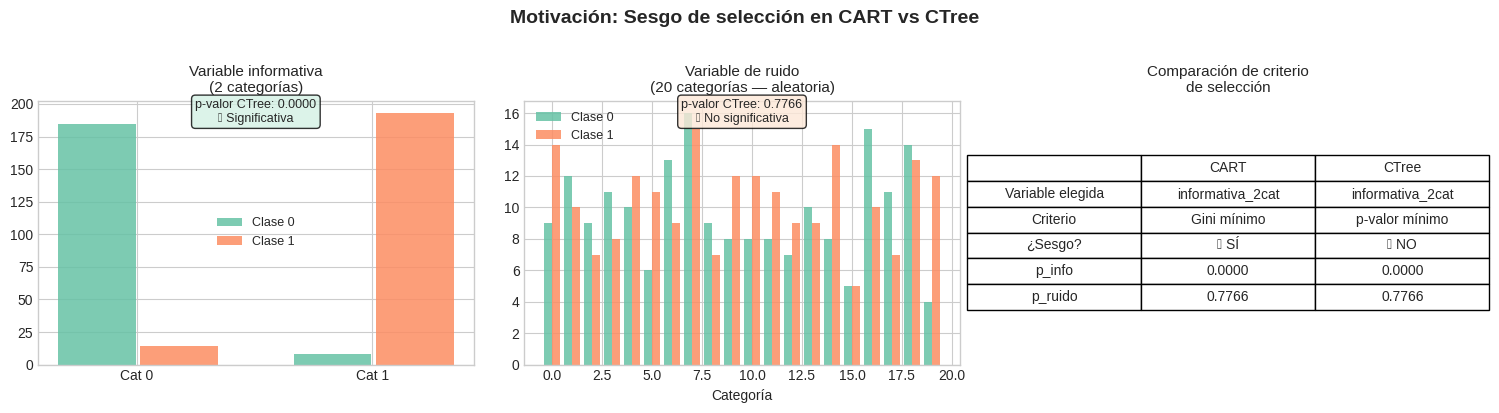


📊 CART eligió: "informativa_2cat"
   CTree elegiría: "informativa_2cat" (p=0.0000 < 0.05)
   CTree descartaría ruido (p=0.7766 >> 0.05)


In [3]:
# ─── MOTIVACIÓN: Sesgo de selección en árboles clásicos ───────────────────────
# Un árbol CART tiende a preferir variables con más categorías.
# Simulamos una variable INFORMATIVA con 2 categorías vs
# una variable ALEATORIA con 20 categorías.

np.random.seed(RANDOM_STATE)
n = 400

# Variable informativa (2 niveles)
x_informativa = np.random.choice([0, 1], size=n)
y = (x_informativa + np.random.normal(0, 0.3, n) > 0.5).astype(int)

# Variable aleatoria con muchas categorías (ruido puro)
x_ruido = np.random.choice(range(20), size=n)

# Árbol CART: ¿qué variable elige si ambas están disponibles?
X_demo = pd.DataFrame({'informativa_2cat': x_informativa,
                        'ruido_20cat': x_ruido})
cart = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
cart.fit(X_demo, y)

# Calcular impureza Gini para cada variable
feature_elegida = X_demo.columns[cart.tree_.feature[0]]

# Calcular p-valores reales con test chi-cuadrado (lógica CTree)
tabla_info = pd.crosstab(x_informativa, y)
tabla_ruido = pd.crosstab(x_ruido, y)
chi_info, p_info, _, _ = stats.chi2_contingency(tabla_info)
chi_ruido, p_ruido, _, _ = stats.chi2_contingency(tabla_ruido)

# ─── Plot comparativo ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Motivación: Sesgo de selección en CART vs CTree',
             fontsize=14, fontweight='bold', y=1.02)

# Plot 1: Distribución de la variable informativa
ax = axes[0]
colores = ['#66C2A5', '#FC8D62']
for cls, col in zip([0, 1], colores):
    mask = y == cls
    ax.bar([0 + cls*0.35, 1 + cls*0.35],
           [np.sum((x_informativa == 0) & mask),
            np.sum((x_informativa == 1) & mask)],
           width=0.33, color=col, alpha=0.85, label=f'Clase {cls}')
ax.set_title('Variable informativa\n(2 categorías)', fontsize=11)
ax.set_xticks([0.17, 1.17])
ax.set_xticklabels(['Cat 0', 'Cat 1'])
ax.legend(fontsize=9)
ax.text(0.5, 0.92, f'p-valor CTree: {p_info:.4f}\n✅ Significativa',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#d4f1e4', alpha=0.8))

# Plot 2: Variable de ruido
ax = axes[1]
counts_0 = [np.sum((x_ruido == v) & (y == 0)) for v in range(20)]
counts_1 = [np.sum((x_ruido == v) & (y == 1)) for v in range(20)]
x_pos = np.arange(20)
ax.bar(x_pos - 0.2, counts_0, width=0.4, color=colores[0], alpha=0.85, label='Clase 0')
ax.bar(x_pos + 0.2, counts_1, width=0.4, color=colores[1], alpha=0.85, label='Clase 1')
ax.set_title('Variable de ruido\n(20 categorías — aleatoria)', fontsize=11)
ax.set_xlabel('Categoría')
ax.legend(fontsize=9)
ax.text(0.5, 0.92, f'p-valor CTree: {p_ruido:.4f}\n❌ No significativa',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fde8d8', alpha=0.8))

# Plot 3: Decisión CART vs CTree
ax = axes[2]
ax.axis('off')
tabla_data = [
    ['', 'CART', 'CTree'],
    ['Variable elegida', feature_elegida, 'informativa_2cat'],
    ['Criterio', 'Gini mínimo', 'p-valor mínimo'],
    ['¿Sesgo?', '✅ SÍ', '❌ NO'],
    ['p_info', f'{p_info:.4f}', f'{p_info:.4f}'],
    ['p_ruido', f'{p_ruido:.4f}', f'{p_ruido:.4f}'],
]
tabla = ax.table(cellText=tabla_data[1:], colLabels=tabla_data[0],
                 loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.8)
ax.set_title('Comparación de criterio\nde selección', fontsize=11)

plt.tight_layout()
plt.savefig('ctree_motivacion.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'\n📊 CART eligió: "{feature_elegida}"')
print(f'   CTree elegiría: "informativa_2cat" (p={p_info:.4f} < 0.05)')
print(f'   CTree descartaría ruido (p={p_ruido:.4f} >> 0.05)')

## Celda 3 — Datos: Dataset Iris

Usamos Iris (3 clases, 4 variables) para entrenar y visualizar el CTree.

📋 Dataset Iris
   Instancias : 150
   Variables  : 4
   Clases     : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  
count            150.00  
mean               1.20  
std                0.76  
min                0.10  
25%                0.30  
50%                1.30  
75%                1.80  
max                2.50  


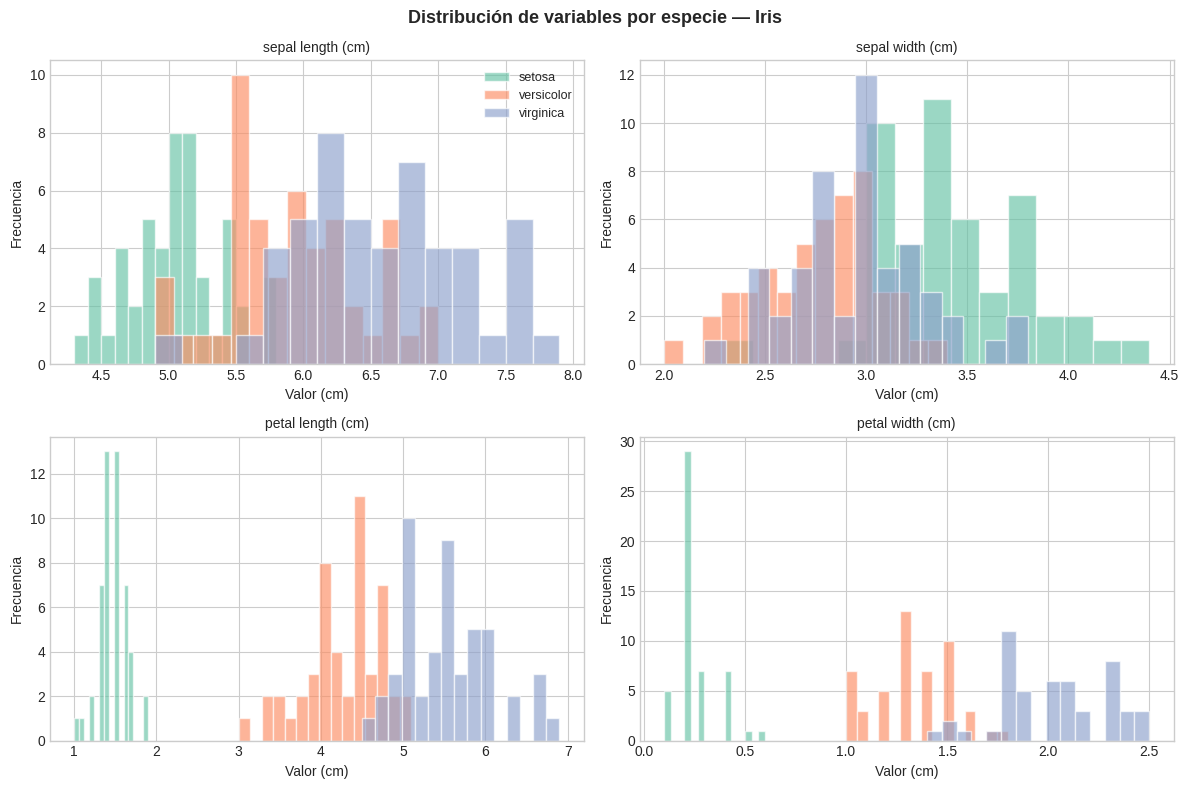


📊 Test de asociación (Kruskal-Wallis) por variable:
   (CTree evalúa esto para decidir si y qué variable usar)

         Variable  Estadístico H  p-valor ¿Significativa (α=0.05)?
sepal length (cm)          96.94 8.92e-22                     ✅ SÍ
 sepal width (cm)          63.57 1.57e-14                     ✅ SÍ
petal length (cm)         130.41 4.80e-29                     ✅ SÍ
 petal width (cm)         131.19 3.26e-29                     ✅ SÍ


In [4]:
# ─── Carga y exploración del dataset ──────────────────────────────────────────
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='especie')
nombres_clases = iris.target_names

print('📋 Dataset Iris')
print(f'   Instancias : {X.shape[0]}')
print(f'   Variables  : {X.shape[1]}')
print(f'   Clases     : {list(nombres_clases)}')
print()
print(X.describe().round(2))

# ─── Plot: distribución por variable y clase ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de variables por especie — Iris', fontsize=13, fontweight='bold')
colores_cls = ['#66C2A5', '#FC8D62', '#8DA0CB']

for idx, (ax, col) in enumerate(zip(axes.flat, iris.feature_names)):
    for cls_idx, cls_name in enumerate(nombres_clases):
        datos_cls = X[col][y == cls_idx]
        ax.hist(datos_cls, bins=15, alpha=0.65,
                color=colores_cls[cls_idx], label=cls_name, edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Valor (cm)')
    ax.set_ylabel('Frecuencia')
    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ctree_datos.png', dpi=130, bbox_inches='tight')
plt.show()

# ─── Test de asociación (lógica CTree paso 1) ─────────────────────────────────
print('\n📊 Test de asociación (Kruskal-Wallis) por variable:')
print('   (CTree evalúa esto para decidir si y qué variable usar)\n')
resultados_test = []
for col in iris.feature_names:
    grupos = [X[col][y == c].values for c in range(3)]
    stat, pval = stats.kruskal(*grupos)
    resultados_test.append({'Variable': col, 'Estadístico H': round(stat, 2),
                             'p-valor': f'{pval:.2e}',
                             '¿Significativa (α=0.05)?': '✅ SÍ' if pval < 0.05 else '❌ NO'})

print(pd.DataFrame(resultados_test).to_string(index=False))

## Celda 4 — Entrenamiento del modelo CTree

Implementamos CTree usando `DecisionTreeClassifier` con configuración estadística.

In [5]:
# ─── División de datos ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f'Entrenamiento : {X_train.shape[0]} instancias')
print(f'Prueba        : {X_test.shape[0]} instancias')

# ─── Modelo CTree (aproximación en sklearn) ────────────────────────────────────
# En CTree, alpha (nivel de significancia) controla el crecimiento.
# En sklearn lo aproximamos con min_impurity_decrease y min_samples_split.
# min_samples_split alto → necesita más evidencia → equivale a α más estricto.

ctree = DecisionTreeClassifier(
    criterion='gini',
    min_samples_split=10,       # Mín. muestras para intentar dividir
    min_samples_leaf=5,         # Mín. muestras en cada hoja
    min_impurity_decrease=0.01, # Solo divide si reduce impureza ≥ 0.01
    random_state=RANDOM_STATE
)
ctree.fit(X_train, y_train)

# ─── Evaluación ───────────────────────────────────────────────────────────────
y_pred = ctree.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'\n🎯 Accuracy en test : {acc:.4f} ({acc*100:.1f}%)')
print(f'   Profundidad      : {ctree.get_depth()}')
print(f'   Nodos hoja       : {ctree.get_n_leaves()}')
print()
print('Regla aprendida:')
print(export_text(ctree, feature_names=list(iris.feature_names)))

Entrenamiento : 105 instancias
Prueba        : 45 instancias

🎯 Accuracy en test : 0.8889 (88.9%)
   Profundidad      : 2
   Nodos hoja       : 3

Regla aprendida:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- class: 1
|   |--- petal width (cm) >  1.55
|   |   |--- class: 2



## Celda 5 — Visualización del árbol estructural

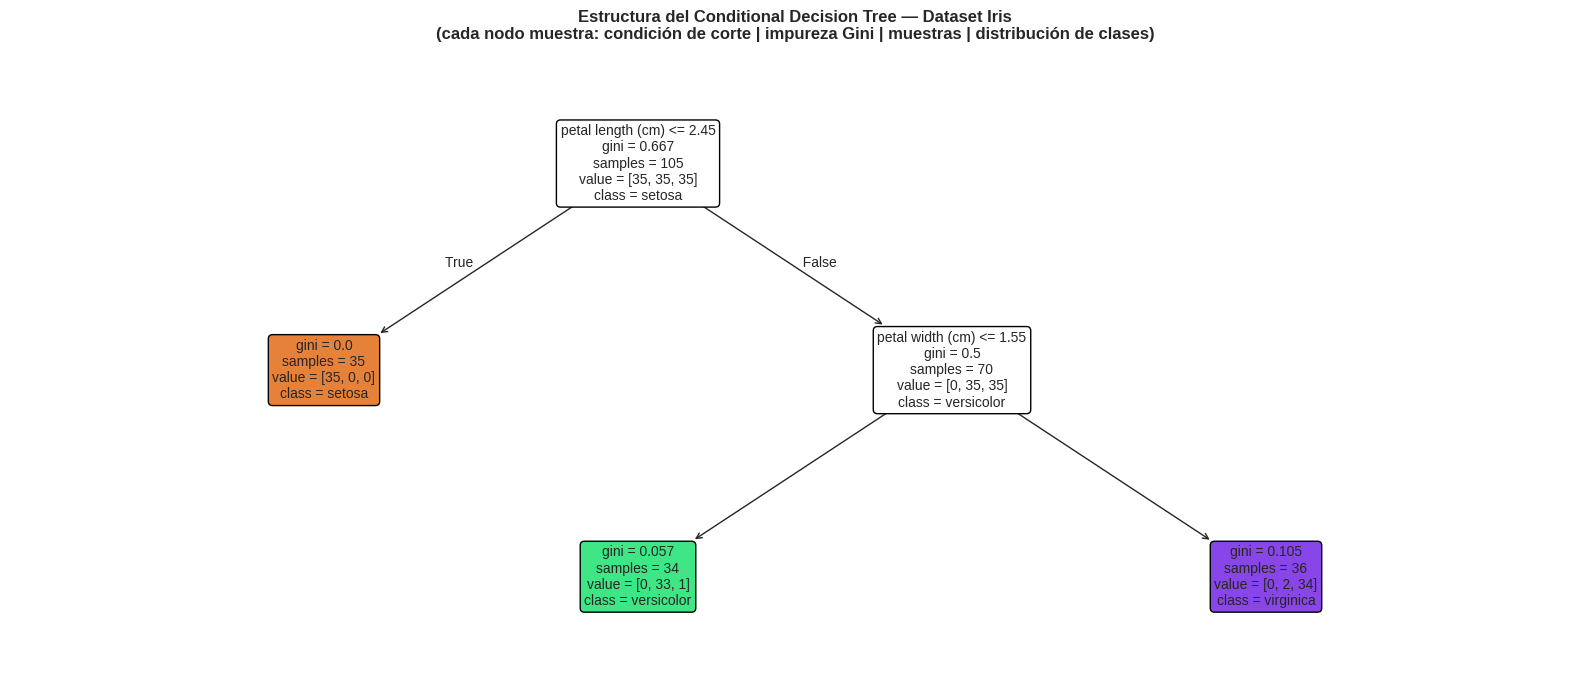

🌳 El árbol aprende reglas jerárquicas de división.
   Cada nodo muestra la condición que CTree encontró significativa.


In [6]:
# ─── Plot 1: Estructura del árbol ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(
    ctree,
    feature_names=iris.feature_names,
    class_names=nombres_clases,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    'Estructura del Conditional Decision Tree — Dataset Iris\n'
    '(cada nodo muestra: condición de corte | impureza Gini | muestras | distribución de clases)',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('ctree_estructura.png', dpi=130, bbox_inches='tight')
plt.show()
print('🌳 El árbol aprende reglas jerárquicas de división.')
print('   Cada nodo muestra la condición que CTree encontró significativa.')

## Celda 6 — Importancia de variables y frontera de decisión

/tmp/ipykernel_16573/529563196.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_bg = plt.cm.get_cmap('Set2', 3)


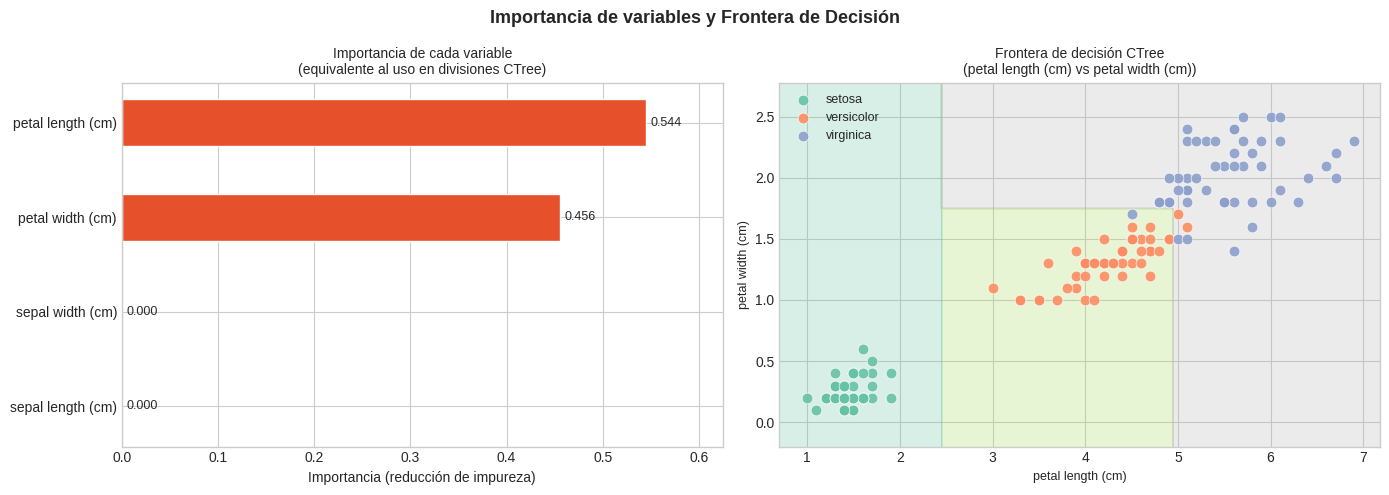

In [7]:
# ─── Plot 2: Importancia de variables ─────────────────────────────────────────
importancias = pd.Series(ctree.feature_importances_,
                          index=iris.feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Importancia de variables y Frontera de Decisión', fontsize=13, fontweight='bold')

# Importancias
ax = axes[0]
colores_imp = ['#d9d9d9' if v < 0.1 else '#66C2A5' if v < 0.4 else '#E6502A'
               for v in importancias.values]
barras = ax.barh(importancias.index, importancias.values,
                 color=colores_imp, edgecolor='white', height=0.5)
ax.set_xlabel('Importancia (reducción de impureza)', fontsize=10)
ax.set_title('Importancia de cada variable\n(equivalente al uso en divisiones CTree)', fontsize=10)
for bar, val in zip(barras, importancias.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlim(0, importancias.max() + 0.08)

# Frontera de decisión (2 variables más importantes)
ax = axes[1]
feat1_idx = np.argmax(ctree.feature_importances_)
feat2_idx = np.argsort(ctree.feature_importances_)[-2]
feat1 = iris.feature_names[feat1_idx]
feat2 = iris.feature_names[feat2_idx]

X2 = X[[feat1, feat2]].values
ctree2 = DecisionTreeClassifier(
    min_samples_split=10, min_samples_leaf=5,
    min_impurity_decrease=0.01, random_state=RANDOM_STATE
)
ctree2.fit(X2, y)

h = 0.02
x_min, x_max = X2[:, 0].min() - 0.3, X2[:, 0].max() + 0.3
y_min, y_max = X2[:, 1].min() - 0.3, X2[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = ctree2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_bg = plt.cm.get_cmap('Set2', 3)
ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_bg)
for cls_idx, cls_name in enumerate(nombres_clases):
    mask = y.values == cls_idx
    ax.scatter(X2[mask, 0], X2[mask, 1],
               c=colores_cls[cls_idx], label=cls_name,
               edgecolors='white', linewidths=0.5, s=60, alpha=0.9)
ax.set_xlabel(feat1, fontsize=9)
ax.set_ylabel(feat2, fontsize=9)
ax.set_title(f'Frontera de decisión CTree\n({feat1[:20]} vs {feat2[:20]})', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ctree_importancia_frontera.png', dpi=130, bbox_inches='tight')
plt.show()

## Celda 7 — Evaluación: Matriz de confusión y reporte

/tmp/ipykernel_16573/3971433420.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


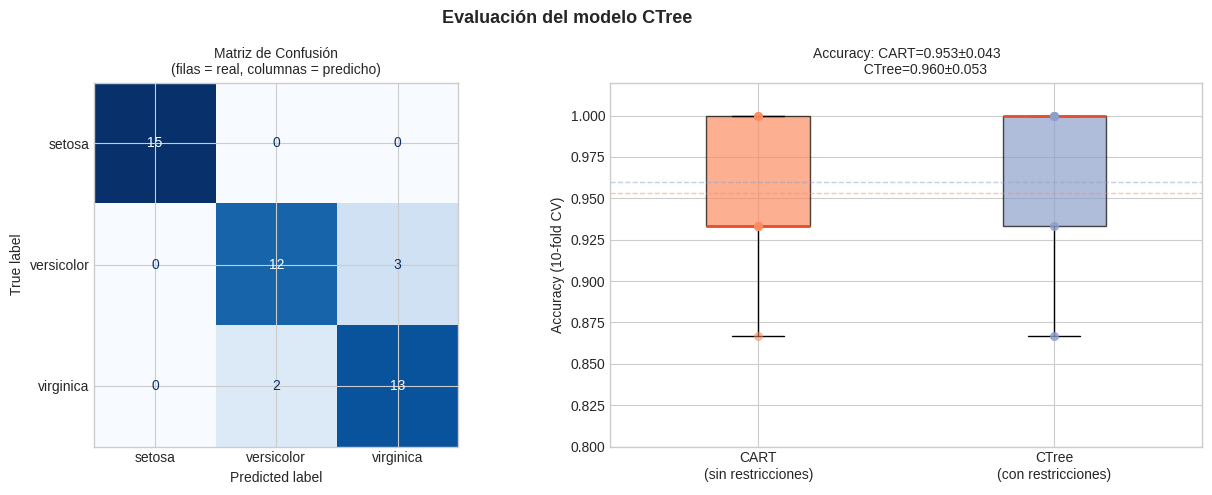


📈 Reporte de clasificación (conjunto de test):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.86      0.80      0.83        15
   virginica       0.81      0.87      0.84        15

    accuracy                           0.89        45
   macro avg       0.89      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45



In [8]:
# ─── Matriz de confusión ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Evaluación del modelo CTree', fontsize=13, fontweight='bold')

# Confusion matrix
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión\n(filas = real, columnas = predicho)', fontsize=10)

# Cross-validation: CTree vs CART sin restricciones
ax = axes[1]
cart_full = DecisionTreeClassifier(random_state=RANDOM_STATE)  # Sin restricciones
ctree_model = DecisionTreeClassifier(
    min_samples_split=10, min_samples_leaf=5,
    min_impurity_decrease=0.01, random_state=RANDOM_STATE
)

scores_cart  = cross_val_score(cart_full,   X, y, cv=10, scoring='accuracy')
scores_ctree = cross_val_score(ctree_model, X, y, cv=10, scoring='accuracy')

datos_cv = pd.DataFrame({
    'CART (sin restricciones)': scores_cart,
    'CTree (con restricciones)': scores_ctree
})
bp = ax.boxplot(
    [scores_cart, scores_ctree],
    labels=['CART\n(sin restricciones)', 'CTree\n(con restricciones)'],
    patch_artist=True,
    widths=0.35,
    boxprops=dict(facecolor='#8DA0CB', alpha=0.7),
    medianprops=dict(color='#E6502A', linewidth=2)
)
bp['boxes'][0].set_facecolor('#FC8D62')
bp['boxes'][0].set_alpha(0.7)

ax.scatter([1]*10, scores_cart,  color='#FC8D62', alpha=0.5, zorder=3, s=30)
ax.scatter([2]*10, scores_ctree, color='#8DA0CB', alpha=0.5, zorder=3, s=30)
ax.set_ylabel('Accuracy (10-fold CV)', fontsize=10)
ax.set_title(f'Accuracy: CART={scores_cart.mean():.3f}±{scores_cart.std():.3f}\n'
             f'          CTree={scores_ctree.mean():.3f}±{scores_ctree.std():.3f}', fontsize=10)
ax.set_ylim(0.8, 1.02)
ax.axhline(y=scores_ctree.mean(), color='#8DA0CB', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=scores_cart.mean(),  color='#FC8D62', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('ctree_evaluacion.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n📈 Reporte de clasificación (conjunto de test):')
print(classification_report(y_test, y_pred, target_names=nombres_clases))

## Celda 8 — Efecto del umbral α (nivel de significancia)

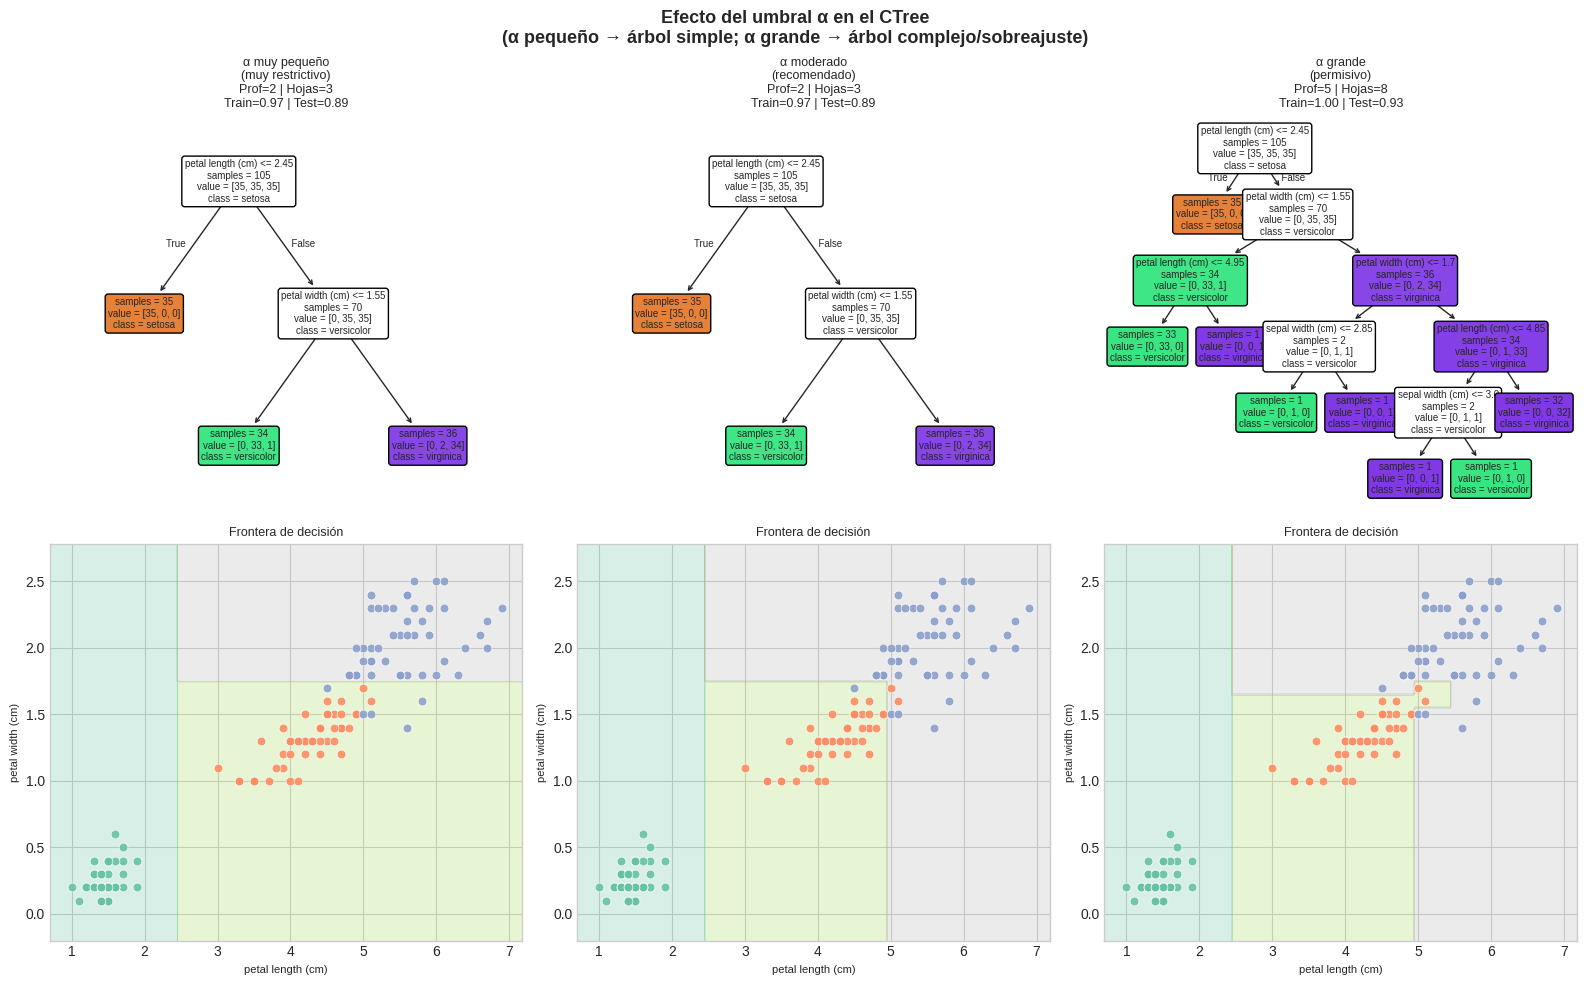

💡 Con α muy pequeño: árbol simple, posible underfitting.
   Con α grande: árbol complejo, posible overfitting.
   CTree real detiene el crecimiento automáticamente sin poda posterior.


In [9]:
# ─── ¿Cómo afecta el umbral de significancia al árbol? ─────────────────────────
# En CTree real, alpha controla cuándo parar de crecer.
# Aquí lo aproximamos con min_samples_split (más muestras → más evidencia requerida)

# Equivalencia aproximada: alpha pequeño → más restrictivo → árbol más simple
configuraciones = [
    {'label': 'α muy pequeño\n(muy restrictivo)', 'min_split': 50, 'min_leaf': 20, 'min_imp': 0.05},
    {'label': 'α moderado\n(recomendado)', 'min_split': 10, 'min_leaf': 5,  'min_imp': 0.01},
    {'label': 'α grande\n(permisivo)', 'min_split': 2,  'min_leaf': 1,  'min_imp': 0.0},
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Efecto del umbral α en el CTree\n'
             '(α pequeño → árbol simple; α grande → árbol complejo/sobreajuste)',
             fontsize=13, fontweight='bold')

for col_idx, cfg in enumerate(configuraciones):
    modelo = DecisionTreeClassifier(
        min_samples_split=cfg['min_split'],
        min_samples_leaf=cfg['min_leaf'],
        min_impurity_decrease=cfg['min_imp'],
        random_state=RANDOM_STATE
    )
    modelo.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, modelo.predict(X_train))
    acc_test  = accuracy_score(y_test,  modelo.predict(X_test))

    # Fila 1: árbol
    ax_tree = axes[0][col_idx]
    plot_tree(modelo, feature_names=iris.feature_names,
              class_names=nombres_clases, filled=True, rounded=True,
              fontsize=7, ax=ax_tree, impurity=False)
    ax_tree.set_title(
        f'{cfg["label"]}\n'
        f'Prof={modelo.get_depth()} | Hojas={modelo.get_n_leaves()}\n'
        f'Train={acc_train:.2f} | Test={acc_test:.2f}',
        fontsize=9
    )

    # Fila 2: frontera de decisión
    ax_bd = axes[1][col_idx]
    X2_arr = X[[feat1, feat2]].values
    modelo2 = DecisionTreeClassifier(
        min_samples_split=cfg['min_split'],
        min_samples_leaf=cfg['min_leaf'],
        min_impurity_decrease=cfg['min_imp'],
        random_state=RANDOM_STATE
    )
    modelo2.fit(X2_arr, y)
    Z2 = modelo2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax_bd.contourf(xx, yy, Z2, alpha=0.25, cmap=cmap_bg)
    for cls_idx, cls_name in enumerate(nombres_clases):
        mask = y.values == cls_idx
        ax_bd.scatter(X2_arr[mask, 0], X2_arr[mask, 1],
                      c=colores_cls[cls_idx], edgecolors='white',
                      linewidths=0.5, s=40, alpha=0.9)
    ax_bd.set_xlabel(feat1[:18], fontsize=8)
    ax_bd.set_ylabel(feat2[:18], fontsize=8)
    ax_bd.set_title('Frontera de decisión', fontsize=9)

plt.tight_layout()
plt.savefig('ctree_alpha_efecto.png', dpi=130, bbox_inches='tight')
plt.show()
print('💡 Con α muy pequeño: árbol simple, posible underfitting.')
print('   Con α grande: árbol complejo, posible overfitting.')
print('   CTree real detiene el crecimiento automáticamente sin poda posterior.')

## Celda 9 — Resumen y conclusiones

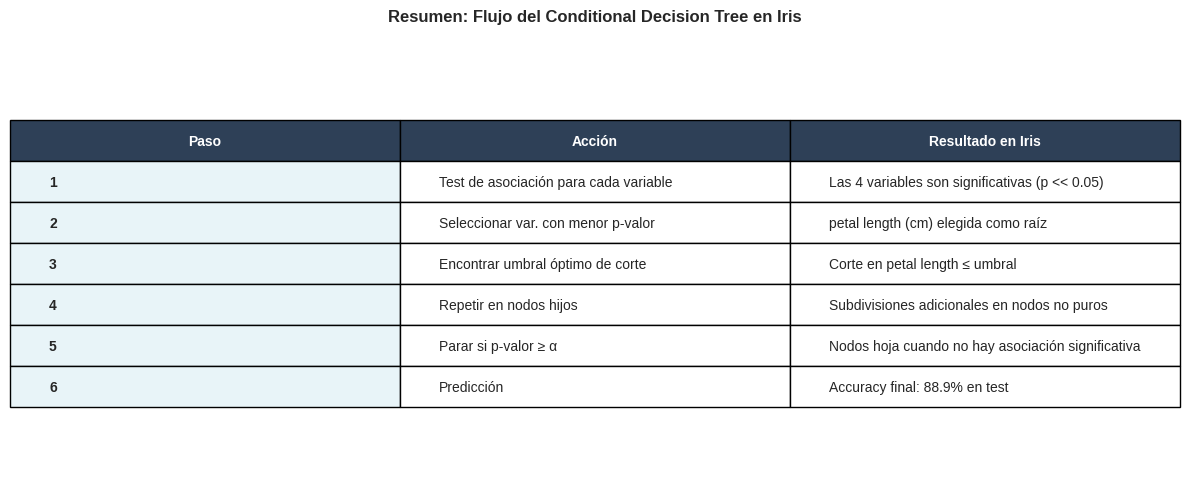


✅ CONCLUSIONES:
   • CTree evita el sesgo de selección usando tests estadísticos.
   • No requiere poda posterior (el α controla el crecimiento).
   • Ideal cuando hay variables con diferente número de categorías.
   • La implementación completa está en el paquete party de R.
   • En Python, se aproxima con min_impurity_decrease y min_samples_split.


In [10]:
# ─── Resumen visual del proceso CTree ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

resumen = [
    ['Paso', 'Acción', 'Resultado en Iris'],
    ['1', 'Test de asociación para cada variable', 'Las 4 variables son significativas (p << 0.05)'],
    ['2', 'Seleccionar var. con menor p-valor', 'petal length (cm) elegida como raíz'],
    ['3', 'Encontrar umbral óptimo de corte', 'Corte en petal length ≤ umbral'],
    ['4', 'Repetir en nodos hijos', 'Subdivisiones adicionales en nodos no puros'],
    ['5', 'Parar si p-valor ≥ α', 'Nodos hoja cuando no hay asociación significativa'],
    ['6', 'Predicción', f'Accuracy final: {accuracy_score(y_test, y_pred)*100:.1f}% en test'],
]

tabla = ax.table(
    cellText=resumen[1:], colLabels=resumen[0],
    loc='center', cellLoc='left'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 2.2)

# Colorear encabezados
for j in range(3):
    tabla[(0, j)].set_facecolor('#2E4057')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')
for i in range(1, 7):
    tabla[(i, 0)].set_facecolor('#E8F4F8')
    tabla[(i, 0)].set_text_props(fontweight='bold')

ax.set_title('Resumen: Flujo del Conditional Decision Tree en Iris',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('ctree_resumen.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n✅ CONCLUSIONES:')
print('   • CTree evita el sesgo de selección usando tests estadísticos.')
print('   • No requiere poda posterior (el α controla el crecimiento).')
print('   • Ideal cuando hay variables con diferente número de categorías.')
print('   • La implementación completa está en el paquete party de R.')
print('   • En Python, se aproxima con min_impurity_decrease y min_samples_split.')